# Notebook 1 -- Data Loading and Exploration

This notebook loads the Open University Learning Analytics Dataset (OULAD),
validates the schema, performs initial cleaning, and provides exploratory
statistics to understand the structure and distributions of the data.

**Objectives:**
- Load all seven OULAD CSV files with correct data types
- Validate schema integrity (expected columns and types)
- Clean missing values and cast types
- Compute summary statistics and visualize key distributions
- Understand the target variable (dropout vs completion)

In [16]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import (
    load_oulad,
    clean_student_info,
    clean_student_vle,
    clean_assessments,
    summarize_dataset,
)
from src.visualization import apply_style, COLORS

apply_style()

print('Libraries loaded successfully.')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

Libraries loaded successfully.
NumPy: 2.4.4
Pandas: 3.0.1


## 1.1 Load Raw Data

The OULAD dataset consists of seven interrelated tables covering student
demographics, course structure, assessments, and virtual learning
environment (VLE) interactions.

In [17]:
DATA_DIR = '/home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/data/raw'

print('Loading OULAD tables...')
tables = load_oulad(DATA_DIR)

Loading OULAD tables...
  Loaded studentInfo: 32,593 rows, 12 columns
  Loaded studentRegistration: 32,593 rows, 5 columns
  Loaded studentAssessment: 173,912 rows, 5 columns
  Loaded studentVle: 10,655,280 rows, 6 columns
  Loaded assessments: 206 rows, 6 columns
  Loaded vle: 6,364 rows, 6 columns
  Loaded courses: 22 rows, 3 columns

All 7 OULAD tables loaded successfully.


In [18]:
# Dataset summary
summary = summarize_dataset(tables)
print('\nDataset Summary:')
print(summary.to_string(index=False))


Dataset Summary:
              table     rows  columns   memory_mb  missing_pct
        studentInfo    32593       12   16.296158         0.28
studentRegistration    32593        5    4.040930        13.85
  studentAssessment   173912        5    6.634342         0.02
         studentVle 10655280        6 1402.310154         0.00
        assessments      206        6    0.035904         0.89
                vle     6364        6    1.130546        27.46
            courses       22        3    0.002518         0.00


## 1.2 Schema Inspection

Examine the first rows and data types of each table to verify
correct loading.

In [19]:
for name, df in tables.items():
    print(f'\n{"=" * 60}')
    print(f'  {name} -- {df.shape[0]:,} rows, {df.shape[1]} columns')
    print(f'{"=" * 60}')
    print(df.dtypes.to_string())
    print(f'\nMissing values:')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        for col, count in missing.items():
            print(f'  {col}: {count:,} ({count/len(df)*100:.1f}%)')
    else:
        print('  None')
    print()


  studentInfo -- 32,593 rows, 12 columns
code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability                str
final_result              str

Missing values:
  imd_band: 1,111 (3.4%)


  studentRegistration -- 32,593 rows, 5 columns
code_module                str
code_presentation          str
id_student               int64
date_registration      float64
date_unregistration    float64

Missing values:
  date_registration: 45 (0.1%)
  date_unregistration: 22,521 (69.1%)


  studentAssessment -- 173,912 rows, 5 columns
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64

Missing values:
  score: 173 (0.1%)


  studentVle -- 10,655,280 rows, 6 columns
code

## 1.3 Target Variable Analysis

The target variable is `final_result` in the studentInfo table.
We define dropout as students whose final result is Withdrawn or Fail.

In [20]:
student_info = clean_student_info(tables['studentInfo'])

# Final result distribution
print('Final Result Distribution:')
result_counts = student_info['final_result'].value_counts()
for result, count in result_counts.items():
    pct = count / len(student_info) * 100
    print(f'  {result}: {count:,} ({pct:.1f}%)')

print(f'\nBinary target (is_dropout):')
print(f'  Dropout:   {student_info["is_dropout"].sum():,} '
      f'({student_info["is_dropout"].mean()*100:.1f}%)')
print(f'  Completed: {(1-student_info["is_dropout"]).sum():,} '
      f'({(1-student_info["is_dropout"]).mean()*100:.1f}%)')

Final Result Distribution:
  Pass: 12,361 (37.9%)
  Withdrawn: 10,156 (31.2%)
  Fail: 7,052 (21.6%)
  Distinction: 3,024 (9.3%)

Binary target (is_dropout):
  Dropout:   17,208 (52.8%)
  Completed: 15,385 (47.2%)


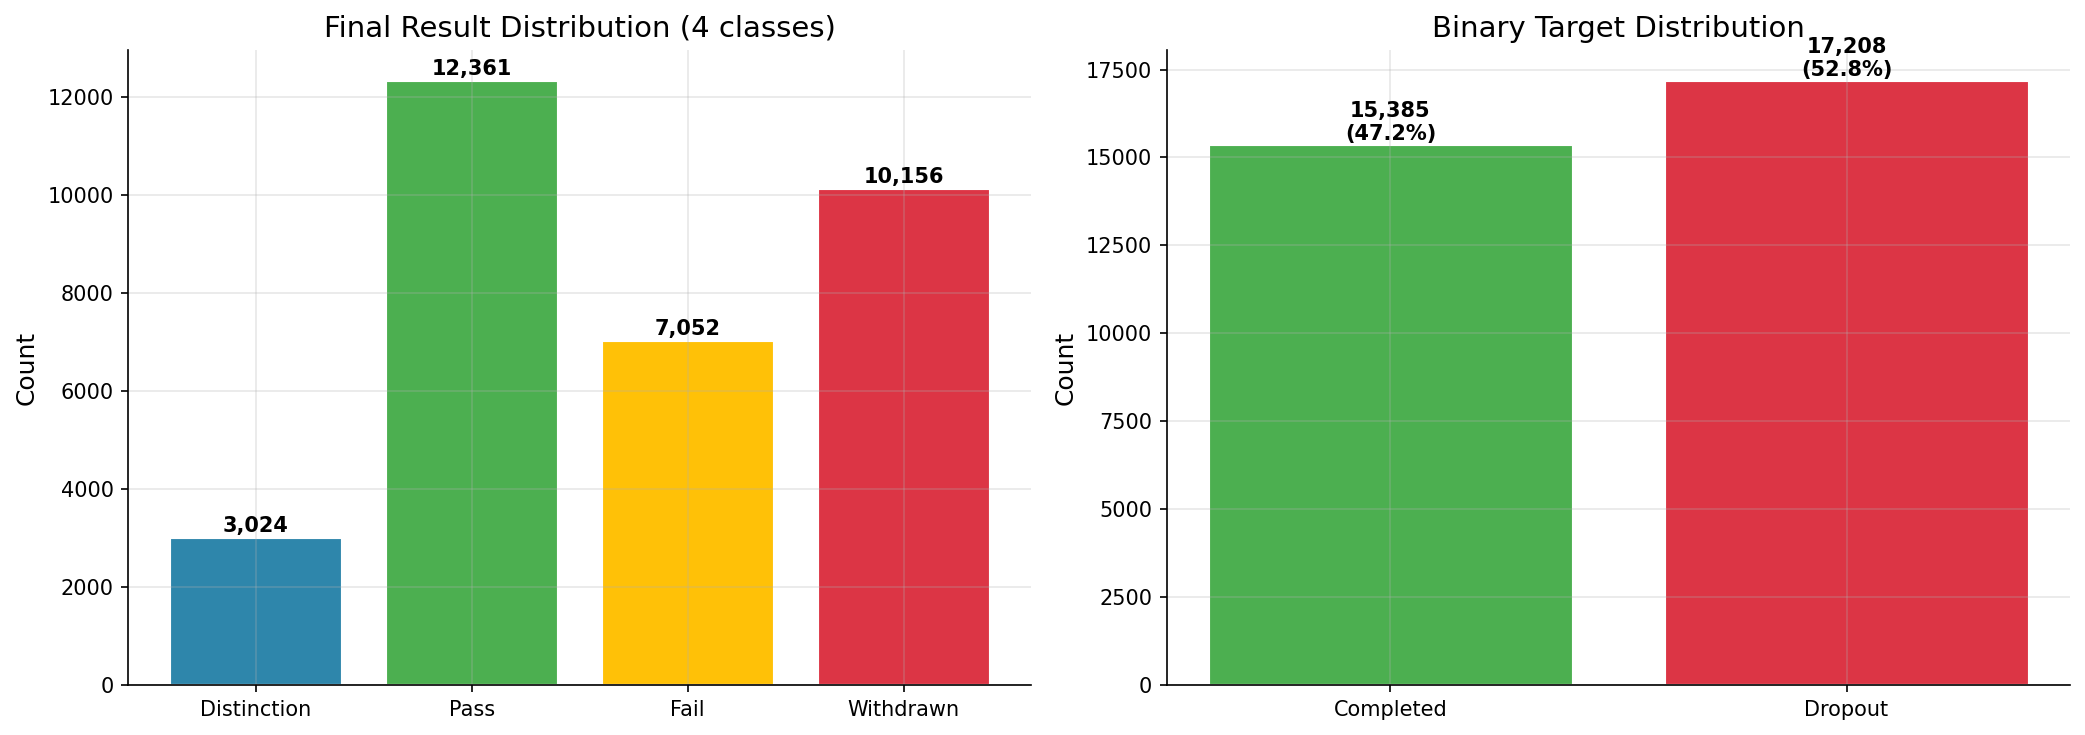

Figure saved: results/figures/target_distribution.png


In [21]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Four-class distribution
ax = axes[0]
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
palette = ['#2E86AB', '#4CAF50', '#FFC107', '#DC3545']
counts = student_info['final_result'].value_counts().reindex(order)
bars = ax.bar(order, counts.values, color=palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Final Result Distribution (4 classes)')

# Binary distribution
ax = axes[1]
binary_counts = student_info['is_dropout'].value_counts().sort_index()
labels = ['Completed', 'Dropout']
colors = [COLORS['completed'], COLORS['dropout']]
bars = ax.bar(labels, binary_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, binary_counts.values):
    pct = val / binary_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Binary Target Distribution')

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/target_distribution.png')

## 1.4 Demographic Analysis

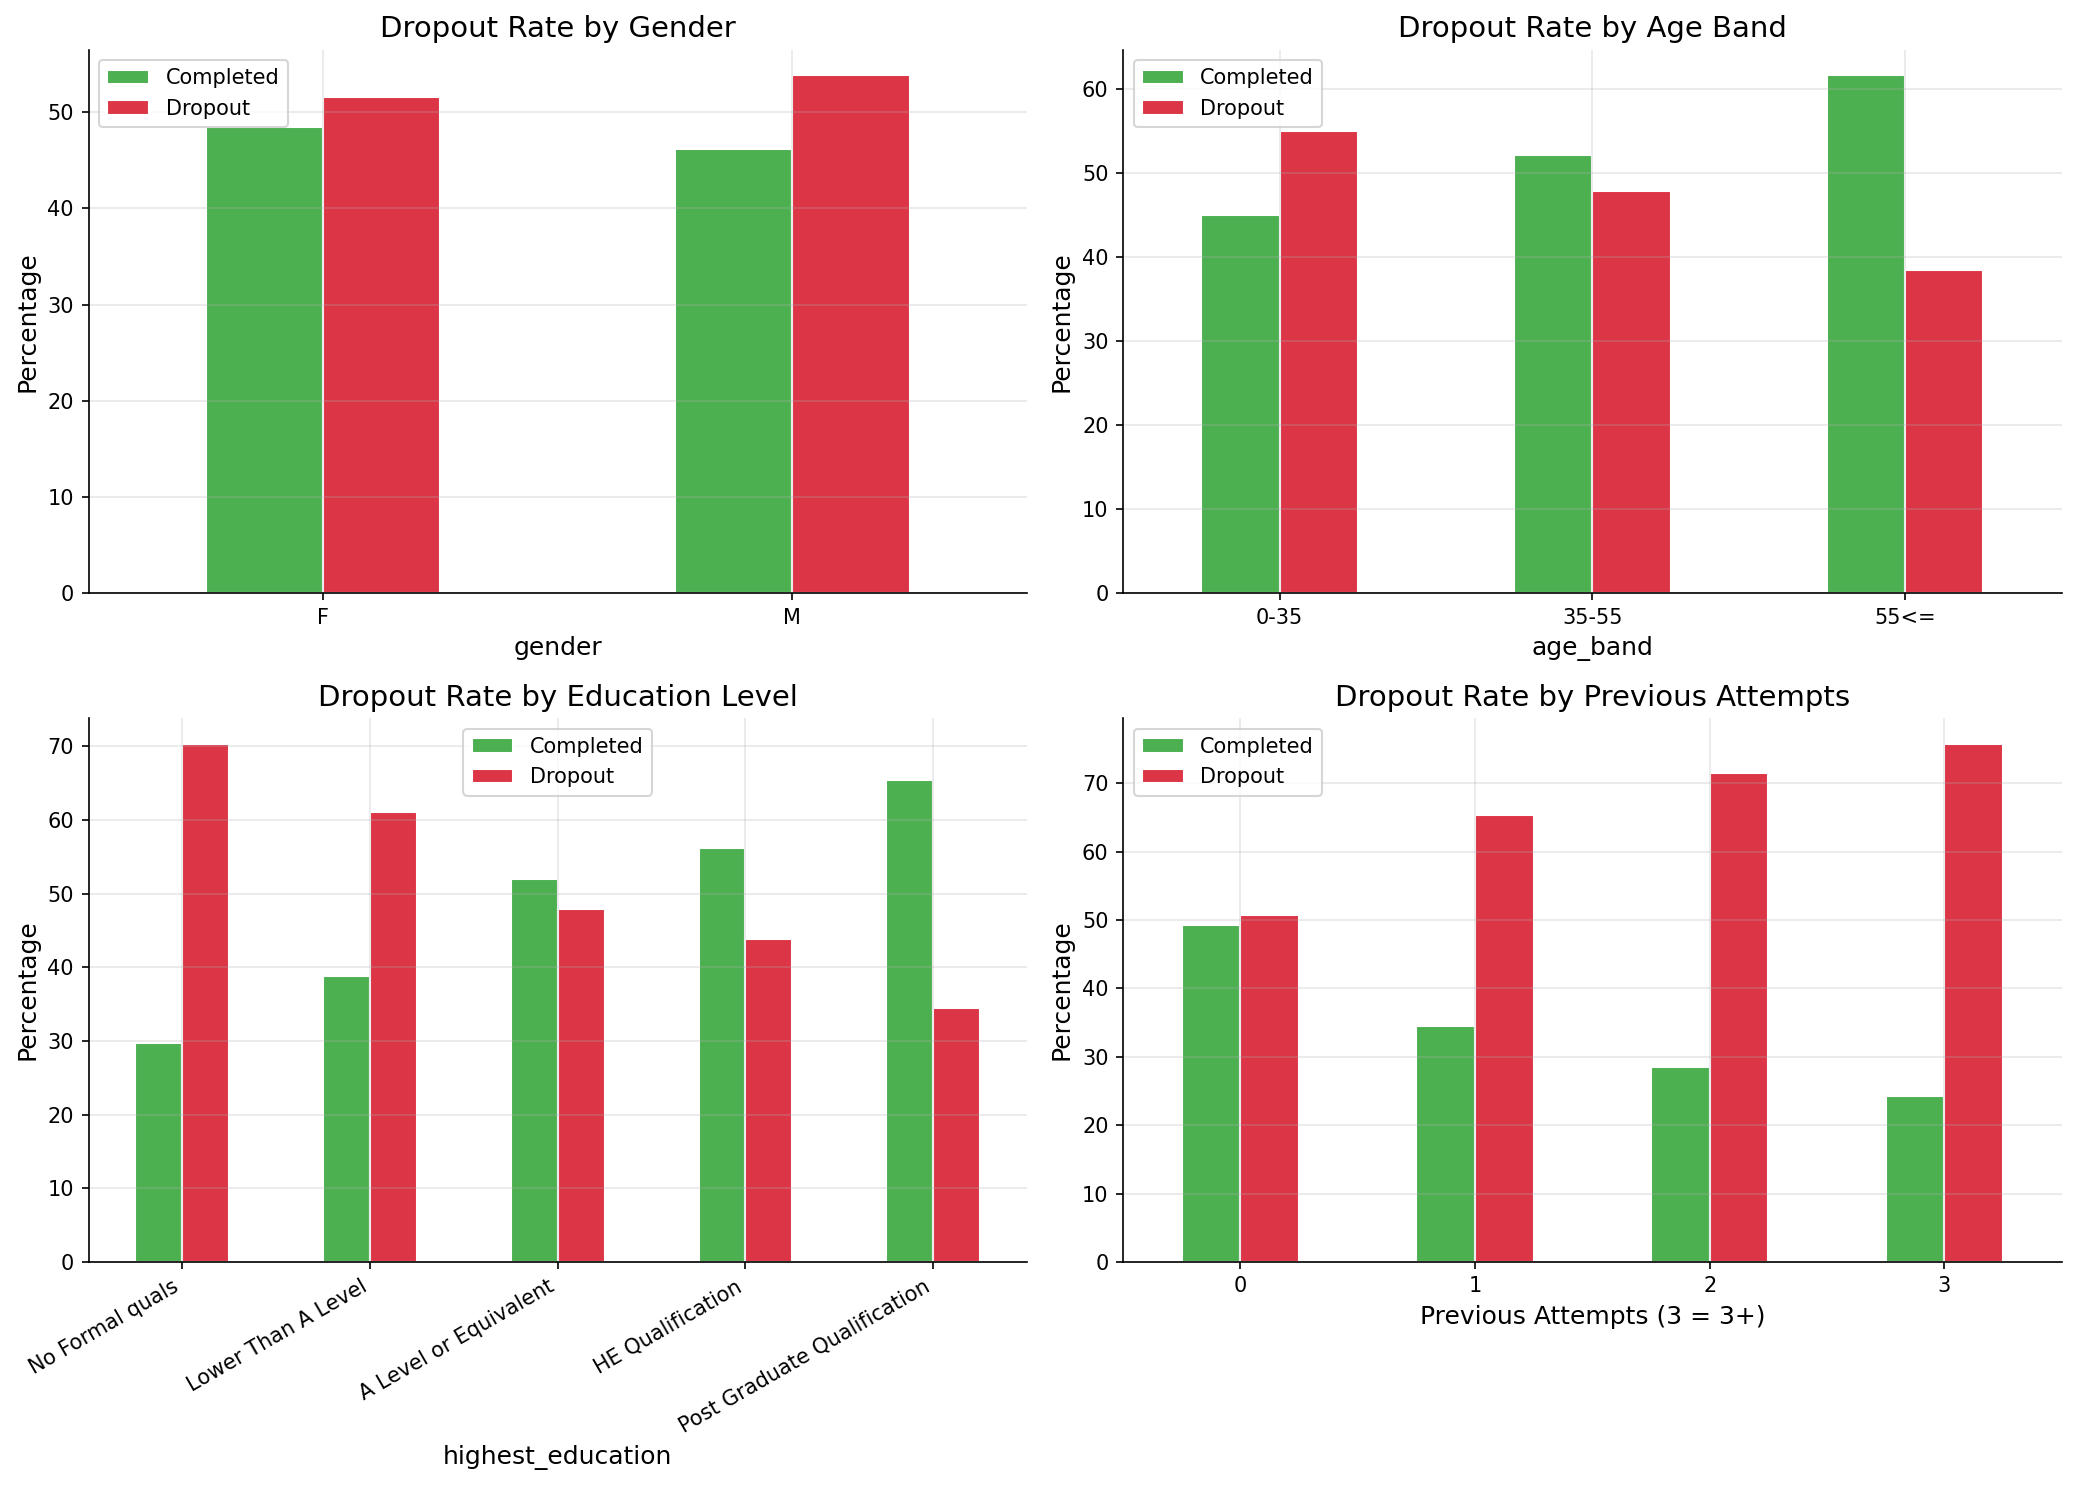

Figure saved: results/figures/demographic_analysis.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender vs outcome
ax = axes[0, 0]
ct = pd.crosstab(student_info['gender'], student_info['is_dropout'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=[COLORS['completed'], COLORS['dropout']],
        edgecolor='white', linewidth=1)
ax.set_title('Dropout Rate by Gender')
ax.set_ylabel('Percentage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Completed', 'Dropout'])

# Age band vs outcome
ax = axes[0, 1]
ct = pd.crosstab(student_info['age_band'], student_info['is_dropout'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=[COLORS['completed'], COLORS['dropout']],
        edgecolor='white', linewidth=1)
ax.set_title('Dropout Rate by Age Band')
ax.set_ylabel('Percentage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Completed', 'Dropout'])

# Education level vs outcome
ax = axes[1, 0]
edu_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
             'HE Qualification', 'Post Graduate Qualification']
ct = pd.crosstab(student_info['highest_education'], student_info['is_dropout'],
                 normalize='index') * 100
ct = ct.reindex(edu_order)
ct.plot(kind='bar', ax=ax, color=[COLORS['completed'], COLORS['dropout']],
        edgecolor='white', linewidth=1)
ax.set_title('Dropout Rate by Education Level')
ax.set_ylabel('Percentage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Completed', 'Dropout'])

# Previous attempts vs outcome
ax = axes[1, 1]
ct = pd.crosstab(student_info['num_of_prev_attempts'].clip(upper=3),
                 student_info['is_dropout'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=[COLORS['completed'], COLORS['dropout']],
        edgecolor='white', linewidth=1)
ax.set_title('Dropout Rate by Previous Attempts')
ax.set_ylabel('Percentage')
ax.set_xlabel('Previous Attempts (3 = 3+)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Completed', 'Dropout'])

plt.tight_layout()
plt.savefig('../results/figures/demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/demographic_analysis.png')

## 1.5 VLE Interaction Overview

In [23]:
student_vle = clean_student_vle(tables['studentVle'])

print('VLE Interaction Summary:')
print(f'  Total interactions: {len(student_vle):,}')
print(f'  Unique students: {student_vle["id_student"].nunique():,}')
print(f'  Date range: {student_vle["date"].min()} to {student_vle["date"].max()}')
print(f'  Click statistics:')
print(student_vle['clicks'].describe().to_string())

VLE Interaction Summary:
  Total interactions: 10,655,280
  Unique students: 26,074
  Date range: -25 to 269
  Click statistics:
count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03


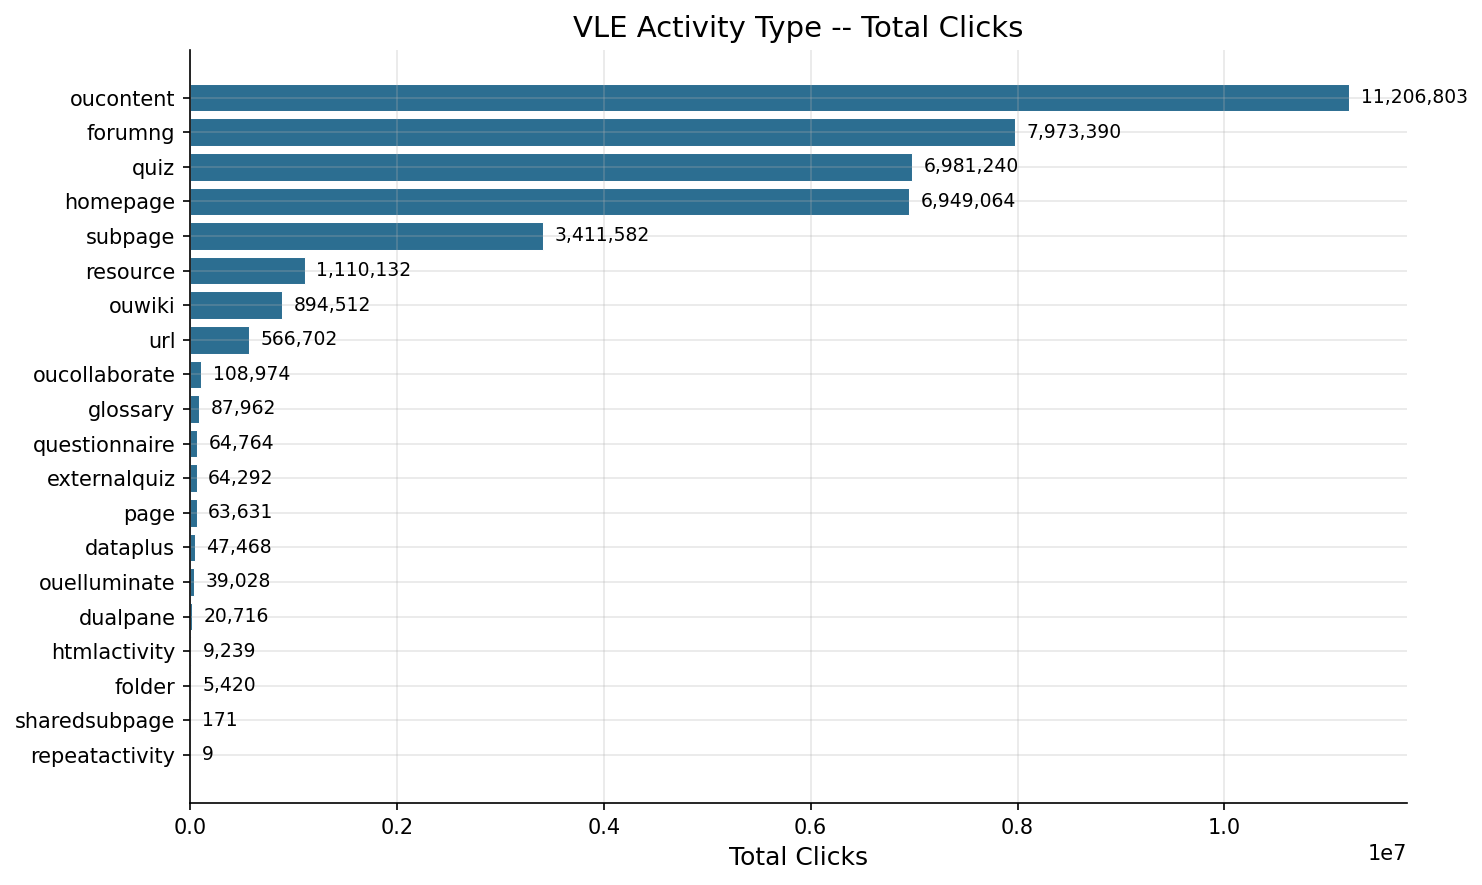

Figure saved: results/figures/activity_type_distribution.png


In [24]:
# Activity type distribution
vle = tables['vle']
merged = student_vle.merge(
    vle[['code_module', 'code_presentation', 'id_site', 'activity_type']],
    on=['code_module', 'code_presentation', 'id_site'],
    how='left'
)

activity_clicks = merged.groupby('activity_type')['clicks'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(activity_clicks.index, activity_clicks.values,
        color=COLORS['primary'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Total Clicks')
ax.set_title('VLE Activity Type -- Total Clicks')
for i, (idx, val) in enumerate(activity_clicks.items()):
    ax.text(val + activity_clicks.max() * 0.01, i, f'{val:,.0f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/activity_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/activity_type_distribution.png')

## 1.6 Assessment Overview

In [25]:
assessments_clean, student_assessment_clean = clean_assessments(
    tables['assessments'], tables['studentAssessment']
)

print('Assessment Summary:')
print(f'  Total assessments defined: {len(assessments_clean):,}')
print(f'  Total submissions: {len(student_assessment_clean):,}')
print(f'  Assessment types: {assessments_clean["assessment_type"].value_counts().to_dict()}')
print(f'\nScore distribution:')
print(student_assessment_clean['score'].describe().to_string())

Assessment Summary:
  Total assessments defined: 206
  Total submissions: 173,912
  Assessment types: {'TMA': 106, 'CMA': 76, 'Exam': 24}

Score distribution:
count    173912.000000
mean         75.724171
std          18.940093
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000


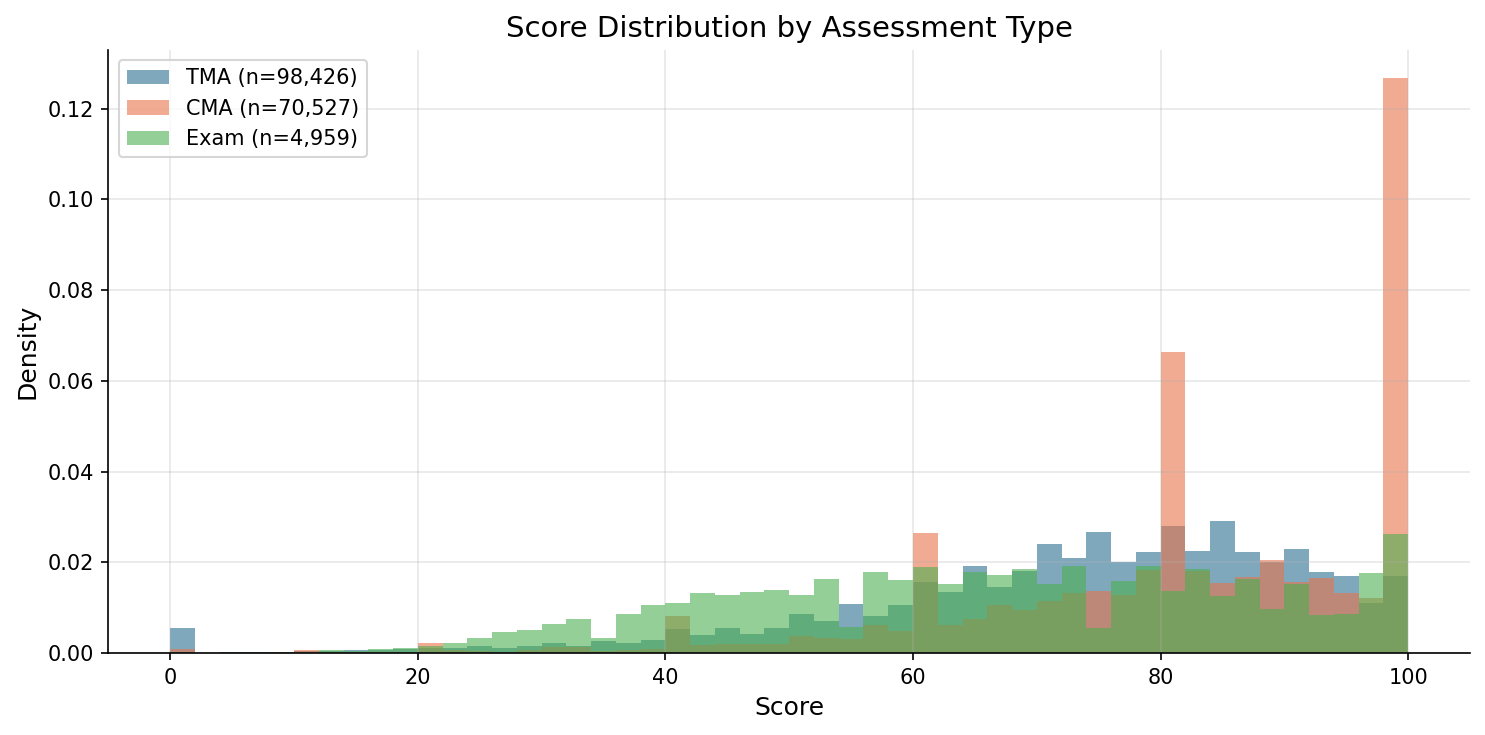

Figure saved: results/figures/score_distribution.png


In [26]:
# Score distribution by assessment type
merged_assess = student_assessment_clean.merge(
    assessments_clean[['id_assessment', 'assessment_type']],
    on='id_assessment', how='left'
)

fig, ax = plt.subplots(figsize=(10, 5))
for i, atype in enumerate(['TMA', 'CMA', 'Exam']):
    subset = merged_assess[merged_assess['assessment_type'] == atype]['score']
    if len(subset) > 0:
        ax.hist(subset, bins=50, alpha=0.6, label=f'{atype} (n={len(subset):,})',
                density=True)
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Assessment Type')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/score_distribution.png')

## 1.7 Course Structure

In [27]:
courses = tables['courses']
print('Courses:')
for _, row in courses.iterrows():
    n_students = len(student_info[
        (student_info['code_module'] == row['code_module']) &
        (student_info['code_presentation'] == row['code_presentation'])
    ])
    print(f'  {row["code_module"]}-{row["code_presentation"]}: '
          f'{row["module_presentation_length"]} days, '
          f'{n_students:,} students')

Courses:
  AAA-2013J: 268 days, 383 students
  AAA-2014J: 269 days, 365 students
  BBB-2013J: 268 days, 2,237 students
  BBB-2014J: 262 days, 2,292 students
  BBB-2013B: 240 days, 1,767 students
  BBB-2014B: 234 days, 1,613 students
  CCC-2014J: 269 days, 2,498 students
  CCC-2014B: 241 days, 1,936 students
  DDD-2013J: 261 days, 1,938 students
  DDD-2014J: 262 days, 1,803 students
  DDD-2013B: 240 days, 1,303 students
  DDD-2014B: 241 days, 1,228 students
  EEE-2013J: 268 days, 1,052 students
  EEE-2014J: 269 days, 1,188 students
  EEE-2014B: 241 days, 694 students
  FFF-2013J: 268 days, 2,283 students
  FFF-2014J: 269 days, 2,365 students
  FFF-2013B: 240 days, 1,614 students
  FFF-2014B: 241 days, 1,500 students
  GGG-2013J: 261 days, 952 students
  GGG-2014J: 269 days, 749 students
  GGG-2014B: 241 days, 833 students


## 1.8 Save Cleaned Data

In [28]:
os.makedirs('../data/processed', exist_ok=True)

student_info.to_csv('../data/processed/studentInfo_clean.csv', index=False)
student_vle.to_csv('../data/processed/studentVle_clean.csv', index=False)
assessments_clean.to_csv('../data/processed/assessments_clean.csv', index=False)
student_assessment_clean.to_csv('../data/processed/studentAssessment_clean.csv', index=False)

print('Cleaned data saved to data/processed/')
print(f'  studentInfo_clean.csv: {len(student_info):,} rows')
print(f'  studentVle_clean.csv: {len(student_vle):,} rows')
print(f'  assessments_clean.csv: {len(assessments_clean):,} rows')
print(f'  studentAssessment_clean.csv: {len(student_assessment_clean):,} rows')

Cleaned data saved to data/processed/
  studentInfo_clean.csv: 32,593 rows
  studentVle_clean.csv: 10,655,280 rows
  assessments_clean.csv: 206 rows
  studentAssessment_clean.csv: 173,912 rows


## Summary

Key observations from this exploration:

1. The dataset contains approximately 32,000 student-module registrations
   across 22 module presentations.

2. The dropout rate (Withdrawn + Fail) is approximately 47%, creating a
   moderately imbalanced but workable binary classification problem.

3. VLE interaction data is the richest source with over 10 million rows,
   covering 20 distinct activity types.

4. Forum (forumng) activity represents a significant but not dominant
   share of VLE interactions, making it a useful signal for NLP analysis.

5. Assessment scores are generally high (mean around 70) but show
   meaningful variation between assessment types.

Next notebook: Feature engineering from these cleaned tables.